In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import numpy as np

import matplotlib.pyplot as plt
from mad.objs.constants import titan_stage_1, titan_stage_2, EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.common_schemas import MovableObject
from mad.objs.missiles import BallisticConfig, MissileStage, StageConfig, BallisticMissile
from mad.objs.guidances import ClosedFormBallistic
from mad.logger import SourceLogger

logger = SourceLogger()

In [42]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

launchpad = earth.create_random_point(name="Launchpad")
target = earth.create_random_point_at_distance(launchpad, distance=7_000_000, name="Target")

earth.escape_velocity, earth.gravity_at_surface, earth.orbital_velocity

(np.float64(11185.79353278485),
 np.float64(-9.819649737724955),
 np.float64(7909.550459984795))

In [36]:
stage1 = MissileStage(StageConfig(**titan_stage_1))
stage2 = MissileStage(StageConfig(**titan_stage_2))

guidance = ClosedFormBallistic(planet=earth, target=target)
titan = BallisticMissile(BallisticConfig(position=launchpad.position.tolist(), stages=[stage1, stage2], name="Titan I", guidance=guidance))

f"dV={titan.deltav:.2f} m/s, range={titan.ballistic_range(earth, gamma_deg=45)/1000:4.2f} km"

'dV=11818.37 m/s, range=15169.85 km'

In [37]:
dt = 1
active_objs = [titan]
inactive_objs = []
for t in range(200000):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)

    active_objs.extend(new_objects)

16:23:43 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
16:23:43 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
16:23:43 | INFO     | Simulation   | Stage1 added to Simulation.
16:23:43 | INFO     | Missile      | Stage2 ran out of propellant at 232.00.
16:23:43 | INFO     | Missile      | Titan I - Stage2 separated at 342.00.
16:23:43 | INFO     | Missile      | Titan I inactivated at 342.00.
16:23:43 | INFO     | Simulation   | Stage2 added to Simulation.
16:23:43 | INFO     | Projectile   | Stage1 landed on the ground!
16:23:43 | INFO     | Projectile   | Stage2 landed on the ground!


In [38]:
def extract_history(objs:list):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)
        time = np.asarray(obj.history.time)

        posx, posz = pos[:, 0], pos[:, 1]
        velx, velz = vel[:, 0], vel[:, 1]

        altitude = np.sqrt(posx**2 + posz**2) - earth.radius
        velout = np.sqrt(velx**2 + velz**2)

        results[obj.name] = {"time": time, "altitude": altitude, "velocity":velout, "posx":posx, "posz":posz}

    return results

results = extract_history(active_objs)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

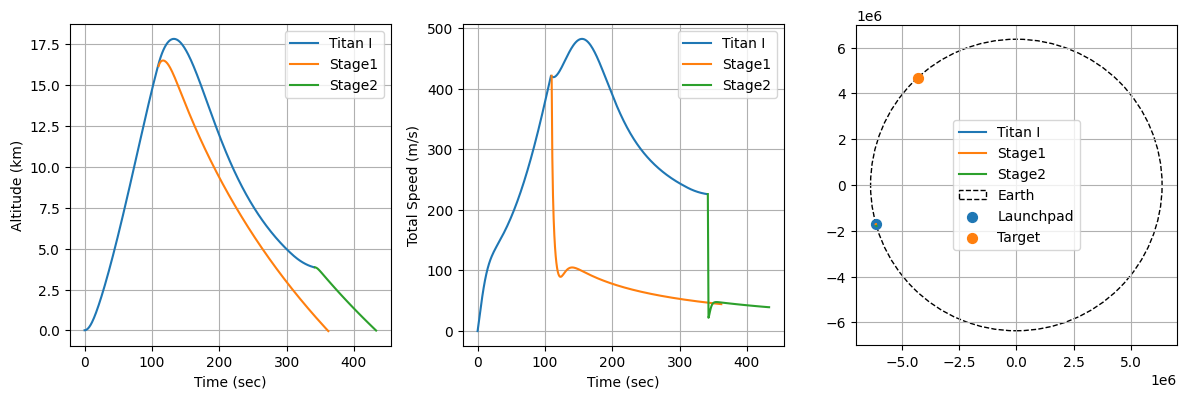

In [39]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

maxx, maxz = 0.0, 0.0
minx, minz= 0.0, 0.0
for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["posx"], result["posz"], label=obj)
    
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()
ax[0].legend()

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[2])


fig.tight_layout(pad=1.2)

In [36]:
f"Distance Impact to target: {earth.surface_distance(target, active_objs[2]) / 1000:.2f} km"

'Distance Impact to target: 5441.72 km'